In [19]:
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from kan import KAN as PyKAN
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from torch import nn, optim
from tqdm import tqdm

plt.rcParams.update({'font.size': 18})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Fault Detection
In this notebook we'll train a `PyKAN` network to distinguish between *faulty* and *not-faulty* operating regimes.

## Load dataset

In [20]:
original_df = pd.read_csv('../dataset/0-original/X.csv').drop(columns=['id', 'pa', 'ias'])
preprocessed_df = pd.read_csv('../dataset/3-classification/X.csv')
predicted_trq_margin_df = pd.read_csv('../2-torque_margin_pdf_regression/prediction.csv')['trq_margin']
df_x = pd.concat([original_df, preprocessed_df, predicted_trq_margin_df], axis=1)
df_y = pd.read_csv('../dataset/3-classification/y.csv')['faulty']

dataset_x = torch.tensor(df_x.values, dtype=torch.float32, device=device)
dataset_y = torch.tensor(df_y.values, dtype=torch.float32, device=device).unsqueeze(1)
assert (dataset_x.shape[0] == dataset_y.shape[0])

In [23]:
# Split the dataset into train, valid, and test sets. Standardize the sets using only training means and stds.
def split_dataset(train_ratio=0.1, max=1) -> tuple[
    tuple[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor]]:
    test_ratio = (max - train_ratio) / 2.0
    size = dataset_x.shape[0]
    np.random.seed(int(time.time()))
    random_indices = np.random.choice(size, size=size, replace=False)

    # Train set
    train_x = dataset_x[random_indices[:int(size * train_ratio)]]
    train_y = dataset_y[random_indices[:int(size * train_ratio)]]
    train_x_mean = train_x.mean(dim=0)
    train_x_std = train_x.std(dim=0)
    train_x = (train_x - train_x_mean) / train_x_std

    # Valid set
    valid_x = dataset_x[random_indices[int(size * train_ratio):int(size * (train_ratio + test_ratio))]]
    valid_y = dataset_y[random_indices[int(size * train_ratio):int(size * (train_ratio + test_ratio))]]
    valid_x = (valid_x - train_x_mean) / train_x_std

    # Test set
    test_x = dataset_x[random_indices[int(size * (train_ratio + test_ratio)):int(size * max)]]
    test_y = dataset_y[random_indices[int(size * (train_ratio + test_ratio)):int(size * max)]]
    test_x = (test_x - train_x_mean) / train_x_std

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)

## Define the train() and test() functions

In [5]:
def score(confidence: torch.Tensor, true_labels: torch.Tensor) -> torch.Tensor:
    pred_labels: torch.Tensor = torch.where(confidence > 0.5, 1, 0)
    confidence = torch.sigmoid(confidence)

    # Mask for valid confidences (between 0 and 1)
    valid_confidence_mask = (confidence >= 0) & (confidence <= 1)
    # Mask for valid labels (0 or 1)
    valid_label_mask = (pred_labels == 0) | (pred_labels == 1)
    # Combined mask for valid inputs
    valid_mask = valid_confidence_mask & valid_label_mask

    # Invert confidence for incorrect predictions
    adjusted_confidence = torch.where(pred_labels == 0, 1 - confidence * 2, (confidence - 0.5) * 2)
    adjusted_confidence = torch.where(pred_labels == true_labels, adjusted_confidence, -adjusted_confidence)

    # Calculate scores for "healthy" (true label == 0)
    healthy_scores = adjusted_confidence.clone()

    # Calculate scores for "faulty" (true label == 1)
    faulty_scores = torch.where(
        adjusted_confidence >= 0,
        adjusted_confidence,
        4 * adjusted_confidence ** 11 + adjusted_confidence
    )

    # Assign scores based on true labels
    scores = torch.where(
        true_labels == 0,
        healthy_scores,
        faulty_scores
    )

    # Only keep scores for valid entries
    scores = torch.where(valid_mask, scores, -100.0)

    return scores

In [6]:
def train(model, trainset, validset, optimizer, epochs, batch_size=8192, false_neg_penalty=2.0, prefix=''):
    train_x, train_y = trainset
    valid_x, valid_y = validset
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([false_neg_penalty]).to(device))
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)
    train_losses = []
    validation_losses = []
    for epoch in range(epochs):
        epoch_train_losses = []
        epoch_validation_losses = []

        # Training
        model.train()
        with tqdm(range(train_x.size(0) // batch_size)) as pbar:
            for i in pbar:
                x = train_x[i * batch_size:(i + 1) * batch_size]
                y = train_y[i * batch_size:(i + 1) * batch_size]
                optimizer.zero_grad()
                confidence = model(x)
                loss = criterion(confidence, y.float())
                loss.backward()
                epoch_train_losses.append(loss.item())
                optimizer.step(closure=lambda: loss)
                pbar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'], epoch=epoch)
        scheduler.step()

        # Validation
        model.eval()
        for i in range(valid_x.size(0) // batch_size):
            x = valid_x[i * batch_size:(i + 1) * batch_size]
            y = valid_y[i * batch_size:(i + 1) * batch_size]
            confidence = model(x)
            loss = criterion(confidence, y.float())
            loss.backward()
            epoch_validation_losses.append(loss.item())

        train_losses.append(np.mean(epoch_train_losses))
        validation_losses.append(np.mean(epoch_validation_losses))

    # Plot losses
    plt.figure(figsize=(24, 8))
    plt.plot(train_losses, label='Training loss')
    plt.plot(validation_losses, label='Validation loss')
    plt.legend()
    plt.savefig(f'img/{prefix}_{datetime.now().ctime().replace(":", "-")}.png')
    plt.close()

In [7]:
def test(model, testset, batch_size=8192) -> tuple[dict, np.ndarray]:
    test_x, test_y = testset
    model.eval()
    scores = []
    score_len = 0
    y_pred = torch.tensor([])

    with torch.no_grad():
        for i in range(test_x.size(0) // batch_size):
            x = test_x[i * batch_size:(i + 1) * batch_size]
            y = test_y[i * batch_size:(i + 1) * batch_size]
            confidence = model(x).squeeze()
            score_t = torch.sum(score(confidence, y.squeeze())).item()
            score_len += confidence.size(0)
            scores.append(score_t)
            y_pred = torch.cat((y_pred, (torch.sigmoid(confidence) > 0.5).cpu()))

    labels = test_y.cpu()[:len(y_pred)].squeeze()
    metrics = {
        'avg_test_score': sum(scores) / score_len,
        'accuracy': accuracy_score(labels, y_pred),
        'precision': precision_score(labels, y_pred),
        'recall': recall_score(labels, y_pred),
        'f1': f1_score(labels, y_pred),
    }
    cm = confusion_matrix(labels, y_pred)
    return metrics, cm

# With CrossEntropyLoss

In [8]:
class Py_KAN(nn.Module):
    def __init__(self, layers, grid_size=3):
        super(Py_KAN, self).__init__()
        self.layers = layers
        self.grid_size = grid_size
        self.model = PyKAN(width=self.layers, grid=self.grid_size, k=3, device=device)

    def forward(self, x):
        return self.model(x)

    def reset(self):
        self.model = PyKAN(width=self.layers, grid=self.grid_size, k=3, device=device)

In [9]:
def multi_train(model: Py_KAN, epochs, prefix='', train_ratio=0.25, times=10, batch_size=8192):
    results = pd.DataFrame(columns=['avg_test_score', 'accuracy', 'precision', 'recall', 'f1'])
    start_date = datetime.now()
    for i in range(times):
        print(f'Time {i + 1}/{times}===========================')
        trainset, validset, testset = split_dataset(train_ratio=train_ratio, max=1)
        model.reset()
        train(model, trainset, validset, optim.Adam(pyKAN.parameters(), lr=0.05), epochs, prefix=prefix,
              batch_size=batch_size)
        metrics, cm = test(model, testset)

        cm_percentage = cm.astype('float') / cm.sum() * 100
        labels = np.array([[f'{value:.2f}%' for value in row] for row in cm_percentage])
        plt.figure(figsize=(16, 10))
        sns.heatmap(cm_percentage, annot=labels, fmt='', cmap="viridis", xticklabels=["Nominal (0)", "Faulty (1)"],
                    yticklabels=["Nominal (0)", "Faulty (1)"])
        plt.xlabel("Predicted label")
        plt.ylabel("Actual label")
        plt.title("Confusion matrix")
        plt.savefig(f'img/{prefix}_confusion_matrix_{i}.png', bbox_inches='tight')
        plt.close()

        results.loc[i] = metrics
        model.model.saveckpt(f'models/fault_detection_{prefix}_{start_date.strftime("%H-%M-%S")}_{i}.pt')
    results.to_csv(f'results/{prefix}_{start_date.strftime("%d %B %y %H-%M-%S")}.csv', index=False)

In [10]:
pyKAN = Py_KAN(layers=[[len(df_x.columns), 0], [1, 0], [1, 0]], grid_size=2)

checkpoint directory created: ./model
saving model version 0.0


In [ ]:
pyKAN.model = PyKAN.loadckpt('models/fault_detection_small_15-45-40_0.pt')
# pyKAN.model = PyKAN.loadckpt('models/fault_detection_multi_23-13-39_8.pt')

In [ ]:
pyKAN = Py_KAN(layers=[[len(df_x.columns), 0], [0, 1], [1, 0]], grid_size=2)
multi_train(pyKAN, prefix='multi', epochs=25, times=10, train_ratio=0.25)
pyKAN = Py_KAN(layers=[[len(df_x.columns), 0], [1, 0], [1, 0]], grid_size=2)
multi_train(pyKAN, prefix='small', epochs=25, times=10, train_ratio=0.25)

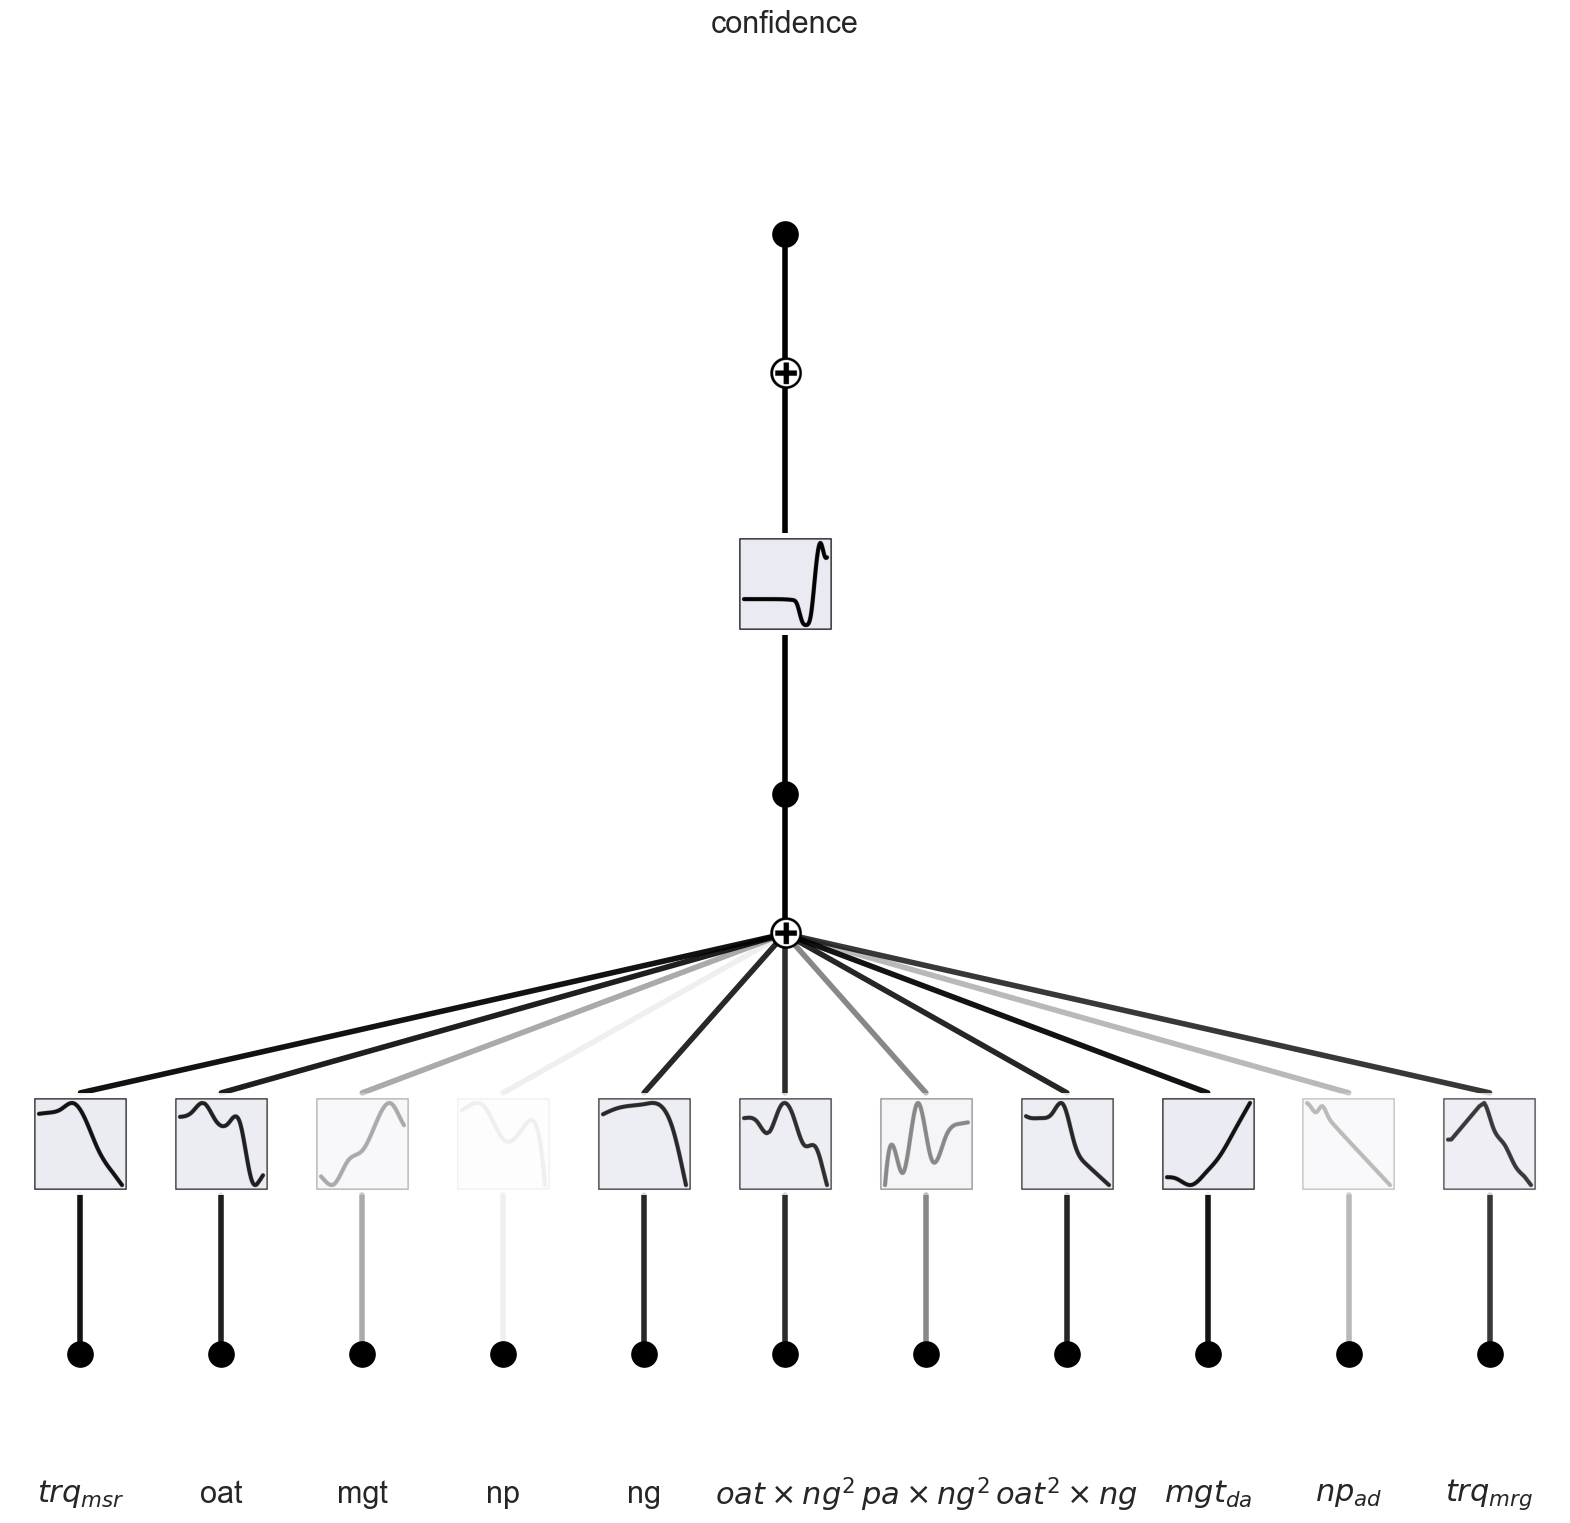

In [31]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$oat\\times ng^2$', '$pa\\times ng^2$', '$oat^2\\times ng$',
           '$mgt_{da}$', '$np_{ad}$', '$trq_{mrg}$']
pyKAN.model.plot(scale=2, in_vars=in_vars, out_vars=['confidence'], varscale=0.275, figsize_base=(10, 10))

In [29]:
trainset, validset, testset = split_dataset(train_ratio=0.01, max=1)
test(pyKAN, testset)

({'avg_test_score': 0.8876514908942309,
  'accuracy': 0.9690440784801136,
  'precision': 0.967005252480338,
  'recall': 0.9559797241606681,
  'f1': 0.9614608806178416},
 array([[210107,   4749],
        [  6409, 139183]], dtype=int64))

Text(0.8824603525884224, 6, '$\\tilde{\\mu}_3$ = -0.535')

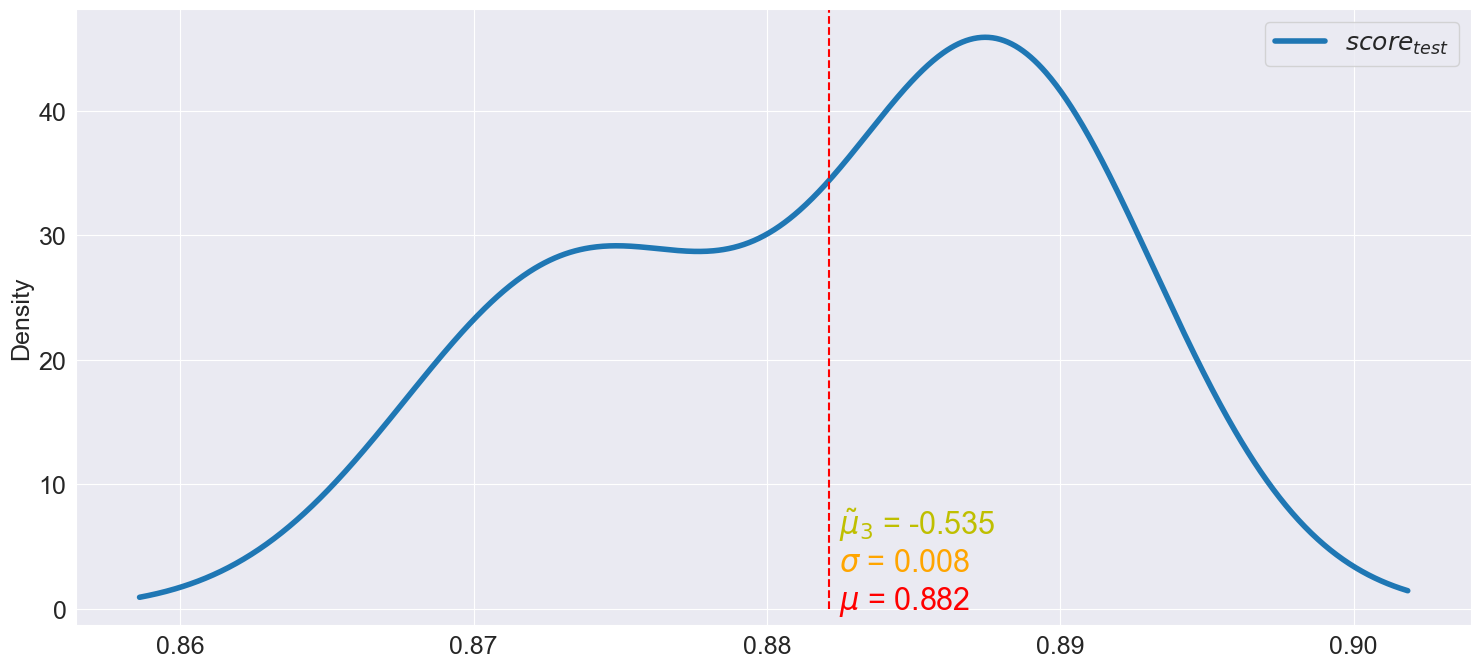

In [122]:
result = pd.read_csv(f'results/multi_09 March 25 23-13-39.csv')
result['training'] = range(1, 11)
ax = result.plot(kind='kde', x='training', y='avg_test_score', figsize=(18, 8), linewidth=4, label='$score_{test}$')
mean = result['avg_test_score'].mean()
skew = result['avg_test_score'].skew()
std = result['avg_test_score'].std()
ax.add_line(Line2D([mean, mean], [0, 144], linestyle='--', color='red'))
ax.text(mean + 0.00035, 0, f'$\\mu$ = {mean:.3f}', fontsize=22, c='r')
ax.text(mean + 0.00035, 3, f'$\\sigma$ = {std:.3f}', fontsize=22, c='orange')
ax.text(mean + 0.00035, 6, f'$\\tilde{"{"}\\mu{"}"}_3$ = {skew:.3f}', fontsize=22, c='y')

Text(0.9619018058968557, 18, '$\\tilde{\\mu}_3$ = 0.505')

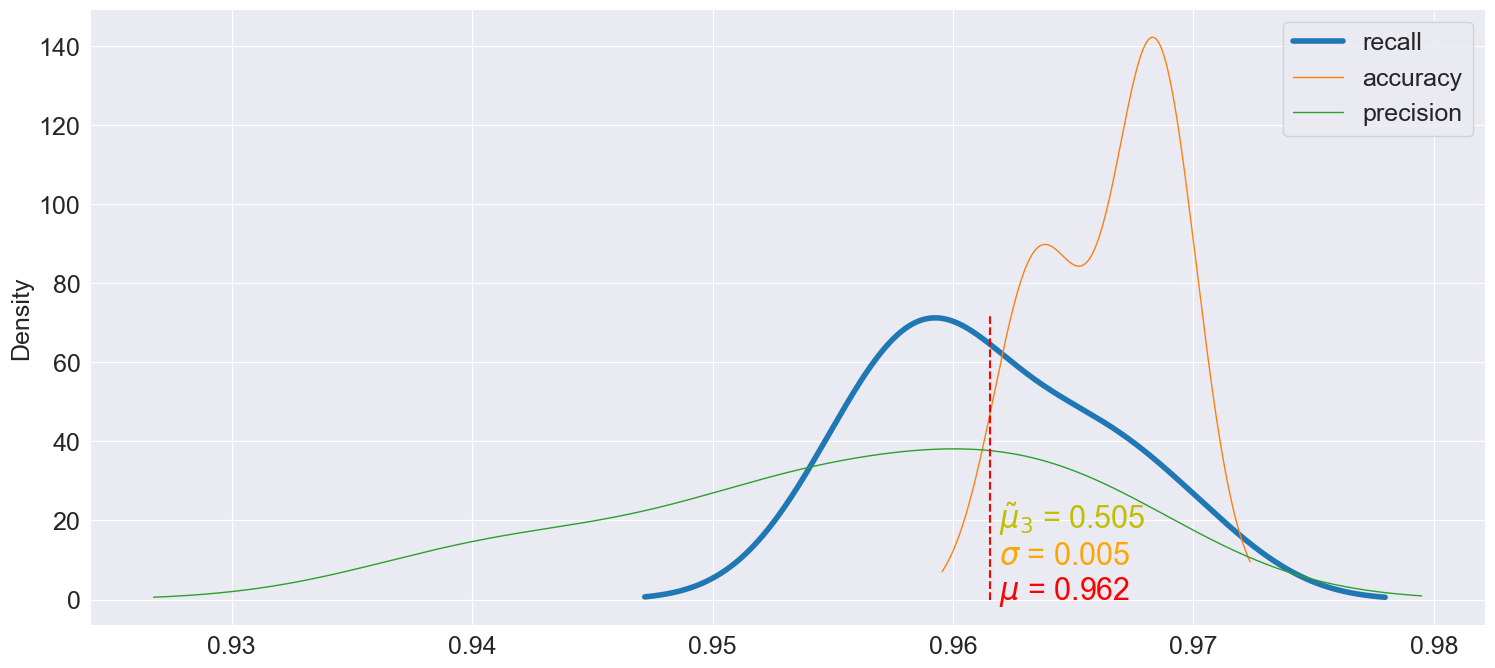

In [124]:
result['training'] = range(1, 11)
ax = result.plot(kind='kde', x='training', y='recall', figsize=(18, 8), linewidth=4)
result.plot(kind='kde', x='training', y='accuracy', figsize=(18, 8), linewidth=1, ax=ax)
result.plot(kind='kde', x='training', y='precision', figsize=(18, 8), linewidth=1, ax=ax)
mean = result['recall'].mean()
skew = result['recall'].skew()
std = result['recall'].std()
ax.add_line(Line2D([mean, mean], [0, 72], linestyle='--', color='r'))
ax.text(mean + 0.00035, 0, f'$\\mu$ = {mean:.3f}', fontsize=22, c='r')
ax.text(mean + 0.00035, 9, f'$\\sigma$ = {std:.3f}', fontsize=22, c='orange')
ax.text(mean + 0.00035, 18, f'$\\tilde{"{"}\\mu{"}"}_3$ = {skew:.3f}', fontsize=22, c='y')